# Descriptive Spatio-Temporal Analytics

The notebook summarizes taxi demand over time and space, trip characteristics, and the effect of choosing different spatial and temporal resolutions.

The main points are:

- coverage of the cleaned data;
- hourly, daily and monthly demand;
- distance, duration and price distributions;
- pickup and drop-off patterns by Community Area;
- gaps between consecutive observed trips; and
- demand sparsity at different spatial and temporal resolutions.

Citywide statistics use `silver_taxi_community_areas_unfiltered`. The resolution comparison uses `silver_taxi_community_areas`, so Community Areas, Census Tracts and H3 grids contain the same trips.

## Methodological scope

One observation is one cleaned taxi trip; demand is measured by trip starts. Published locations are area centroids rather than exact addresses, so the maps show aggregated demand rather than routes or street-level activity.

Distance, duration and monetary variables are right-skewed. Their summaries therefore report medians and upper quantiles as well as means. Temporal profiles average comparable calendar periods so that weekdays or months with more observations do not receive extra weight.

In [37]:
from pathlib import Path

import duckdb
import geopandas as gpd
import h3
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from run_config import (
    END_DATE,
    GOLD_TIME_UNITS,
    H3_RESOLUTION,
    PATHS,
    RUN_MODE,
    START_DATE,
)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

FULL_TRIPS_PATH = PATHS.silver_taxi_community_areas_unfiltered
COMMON_TRIPS_PATH = PATHS.silver_taxi_community_areas
COMMUNITY_PATH = PATHS.silver_community_areas

for path in (FULL_TRIPS_PATH, COMMON_TRIPS_PATH, COMMUNITY_PATH):
    if not path.exists():
        raise FileNotFoundError(f"Required input is missing: {path}")

print(f"Run mode: {RUN_MODE}")
print(f"Configured interval: [{START_DATE}, {END_DATE})")
print(f"Complete cleaned trips: {FULL_TRIPS_PATH}")
print(f"Common spatial-comparison population: {COMMON_TRIPS_PATH}")
print(f"Configured H3 resolutions: {H3_RESOLUTION}")
print(f"Configured Gold time units: {GOLD_TIME_UNITS}")

if set(H3_RESOLUTION) != {7, 8}:
    raise ValueError(f"This analysis requires H3 resolutions (7, 8), got {H3_RESOLUTION}")
if set(GOLD_TIME_UNITS) != {"1h", "4h", "24h"}:
    raise ValueError(
        "This analysis requires the time-unit configuration "
        f"('1h', '4h', '24h'), got {GOLD_TIME_UNITS}"
    )

Run mode: full
Configured interval: [2024-01-01T00:00:00, 2026-05-01T00:00:00)
Complete cleaned trips: /Users/moritz/Documents/Master Studium/Advanced Analytics and Application/assignment/Group-3-AAA/data/full/processed_data/silver_taxi_community_areas_UNFILTERED.parquet
Common spatial-comparison population: /Users/moritz/Documents/Master Studium/Advanced Analytics and Application/assignment/Group-3-AAA/data/full/processed_data/silver_taxi_community_areas.parquet
Configured H3 resolutions: (7, 8)
Configured Gold time units: ('1h', '4h', '24h')


In [38]:
con = duckdb.connect()
con.execute("SET threads = 4")
con.execute("SET preserve_insertion_order = false")

full_trips_file = FULL_TRIPS_PATH.as_posix().replace("'", "''")
common_trips_file = COMMON_TRIPS_PATH.as_posix().replace("'", "''")
con.execute(
    f"CREATE OR REPLACE VIEW full_trips AS SELECT * FROM read_parquet('{full_trips_file}')"
)
con.execute(
    f"CREATE OR REPLACE VIEW common_trips AS SELECT * FROM read_parquet('{common_trips_file}')"
)

## Data coverage and analytical populations

General summaries include every cleaned trip in the unfiltered Silver dataset. The spatial-resolution comparison is restricted to trips available for Community Areas, Census Tracts and both H3 grids. This keeps the underlying trips fixed when the resolution changes.

In [39]:
coverage = con.sql("""
WITH full_summary AS (
    SELECT
        COUNT(*) AS trips,
        COUNT(DISTINCT trip_id) AS distinct_trip_ids,
        COUNT(DISTINCT taxi_id) AS distinct_taxi_ids,
        MIN(trip_start_timestamp) AS first_trip,
        MAX(trip_start_timestamp) AS last_trip,
        COUNT(pickup_community_area) AS pickup_area_available,
        COUNT(dropoff_community_area) AS dropoff_area_available,
        COUNT(pickup_census_tract_source) AS source_census_available,
        COUNT(pickup_census_tract) AS canonical_census_available
    FROM full_trips
), common_summary AS (
    SELECT COUNT(*) AS common_trips FROM common_trips
)
SELECT
    f.*,
    c.common_trips,
    ROUND(100.0 * c.common_trips / f.trips, 2) AS common_population_pct,
    ROUND(100.0 * f.pickup_area_available / f.trips, 2) AS pickup_area_coverage_pct,
    ROUND(100.0 * f.dropoff_area_available / f.trips, 2) AS dropoff_area_coverage_pct,
    ROUND(100.0 * f.source_census_available / f.trips, 2) AS source_census_coverage_pct,
    ROUND(100.0 * f.canonical_census_available / f.trips, 2) AS canonical_census_coverage_pct
FROM full_summary f CROSS JOIN common_summary c
""").df()

display(coverage.T.rename(columns={0: "value"}))

assert coverage.loc[0, "trips"] == coverage.loc[0, "distinct_trip_ids"]
assert coverage.loc[0, "common_trips"] <= coverage.loc[0, "trips"]
assert coverage.loc[0, "first_trip"] >= pd.Timestamp(START_DATE)
assert coverage.loc[0, "last_trip"] < pd.Timestamp(END_DATE)

,value
trips,13386706
distinct_trip_ids,13386706
distinct_taxi_ids,3313
first_trip,2024-01-01 00:00:00
last_trip,2026-04-30 23:45:00
pickup_area_available,13386706
dropoff_area_available,12376468
source_census_available,6049435
canonical_census_available,6049435
common_trips,6049435


In [40]:
mapping_quality = con.sql("""
SELECT
    pickup_census_mapping_method AS mapping_method,
    COUNT(*) AS trips,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS trip_share_pct
FROM full_trips
GROUP BY 1
ORDER BY trips DESC
""").df()

display(mapping_quality)

,mapping_method,trips,trip_share_pct
0,missing_source_id,7337271,54.810
1,centroid_crosswalk,3218779,24.040
2,source_id_matches_dimension,2830656,21.150


## Overall trip characteristics

Duplicates and implausible records were removed during preparation. The remaining distance, duration and fare distributions are still right-skewed, so means are reported together with medians and quantiles.

In [41]:
trip_summary = con.sql("""
SELECT * FROM (
    SELECT 'Distance (miles)' AS metric,
           AVG(trip_miles) AS mean,
           MEDIAN(trip_miles) AS median,
           QUANTILE_CONT(trip_miles, 0.25) AS p25,
           QUANTILE_CONT(trip_miles, 0.75) AS p75,
           QUANTILE_CONT(trip_miles, 0.95) AS p95,
           QUANTILE_CONT(trip_miles, 0.99) AS p99
    FROM full_trips
    UNION ALL
    SELECT 'Duration (minutes)',
           AVG(trip_seconds) / 60.0,
           MEDIAN(trip_seconds) / 60.0,
           QUANTILE_CONT(trip_seconds, 0.25) / 60.0,
           QUANTILE_CONT(trip_seconds, 0.75) / 60.0,
           QUANTILE_CONT(trip_seconds, 0.95) / 60.0,
           QUANTILE_CONT(trip_seconds, 0.99) / 60.0
    FROM full_trips
    UNION ALL
    SELECT 'Fare (USD)',
           AVG(fare), MEDIAN(fare),
           QUANTILE_CONT(fare, 0.25), QUANTILE_CONT(fare, 0.75),
           QUANTILE_CONT(fare, 0.95), QUANTILE_CONT(fare, 0.99)
    FROM full_trips
    UNION ALL
    SELECT 'Trip total (USD)',
           AVG(trip_total), MEDIAN(trip_total),
           QUANTILE_CONT(trip_total, 0.25), QUANTILE_CONT(trip_total, 0.75),
           QUANTILE_CONT(trip_total, 0.95), QUANTILE_CONT(trip_total, 0.99)
    FROM full_trips
)
""").df().set_index("metric")

display(trip_summary.round(2))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,mean,median,p25,p75,p95,p99
metric,,,,,,
Distance (miles),7.150,3.910,1.410,12.240,18.410,26.800
Duration (minutes),21.060,16.050,9.000,28.470,53.550,75.000
Fare (USD),22.070,15.250,8.540,33.500,49.500,69.750
Trip total (USD),27.110,17.810,10.530,40.690,65.620,96.000


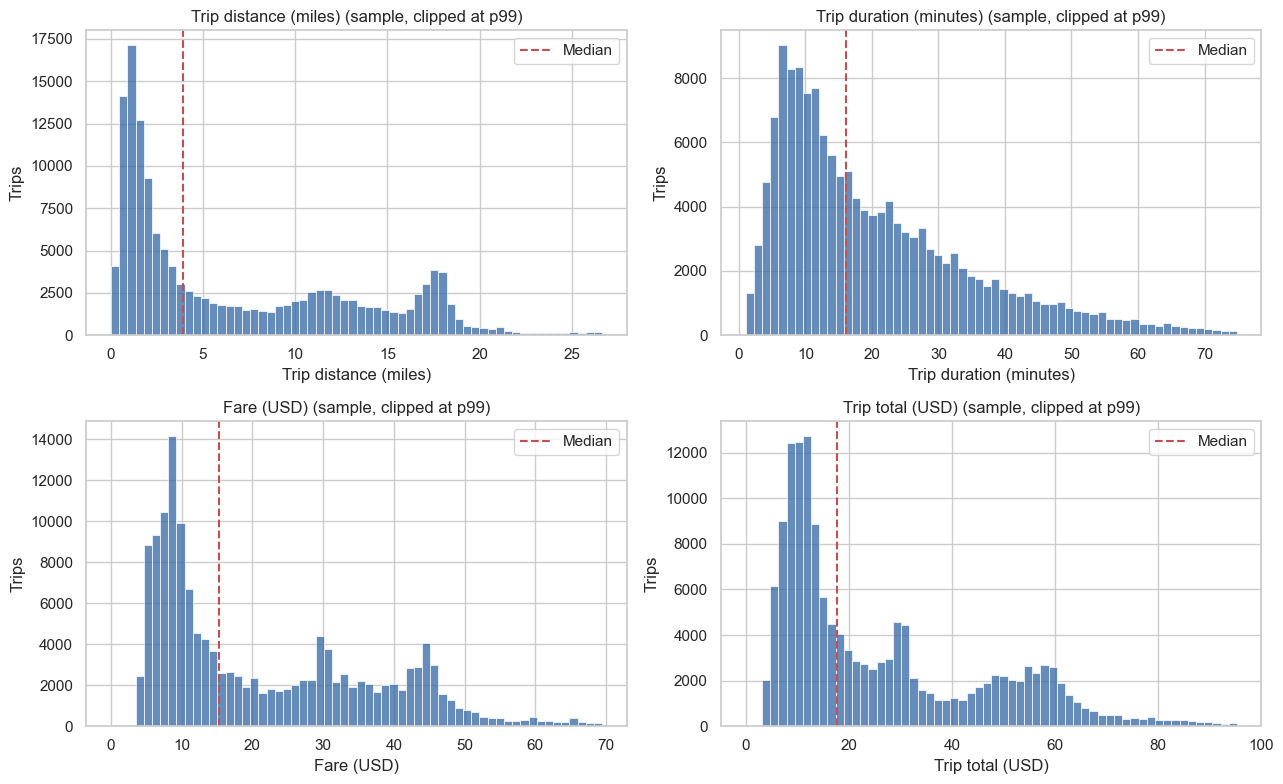

In [42]:
distribution_sample = con.execute("""
SELECT
    trip_miles,
    trip_seconds / 60.0 AS trip_minutes,
    fare,
    trip_total
FROM full_trips
USING SAMPLE 150000 ROWS (reservoir, 42)
""").df()

plot_specs = [
    ("trip_miles", "Trip distance (miles)"),
    ("trip_minutes", "Trip duration (minutes)"),
    ("fare", "Fare (USD)"),
    ("trip_total", "Trip total (USD)"),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, (column, label) in zip(axes.flat, plot_specs):
    upper = distribution_sample[column].quantile(0.99)
    sns.histplot(
        distribution_sample.loc[distribution_sample[column] <= upper, column],
        bins=60,
        color="#3366a6",
        ax=ax,
    )
    ax.axvline(distribution_sample[column].median(), color="#c44e52", linestyle="--", label="Median")
    ax.set(title=f"{label} (sample, clipped at p99)", xlabel=label, ylabel="Trips")
    ax.legend()

fig.tight_layout()
plt.show()

## Temporal demand patterns

Demand is counted at the trip start. Hourly and weekday profiles are calculated from date-hour totals, which avoids weighting a weekday more heavily simply because it occurs more often in the observation period.

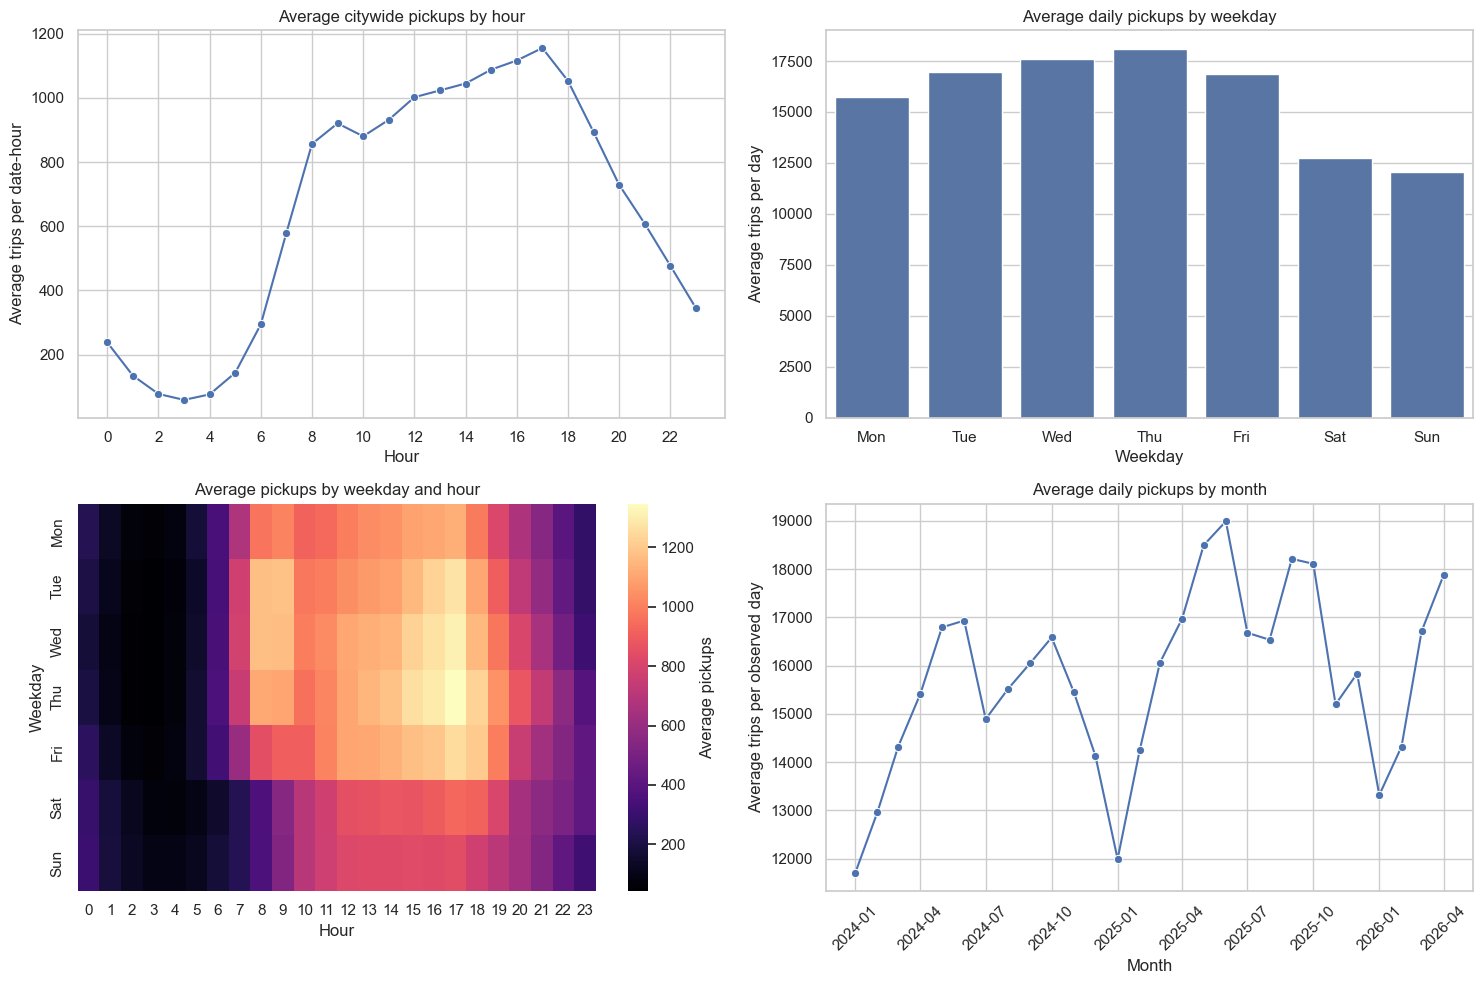

In [43]:
date_hour_demand = con.sql("""
SELECT
    CAST(trip_start_timestamp AS DATE) AS trip_date,
    EXTRACT('isodow' FROM trip_start_timestamp)::INTEGER AS weekday,
    EXTRACT('hour' FROM trip_start_timestamp)::INTEGER AS hour,
    COUNT(*) AS trips
FROM full_trips
GROUP BY 1, 2, 3
""").df()

weekday_labels = {1: "Mon", 2: "Tue", 3: "Wed", 4: "Thu", 5: "Fri", 6: "Sat", 7: "Sun"}

hour_profile = date_hour_demand.groupby("hour", as_index=False).trips.mean()
weekday_profile = (
    date_hour_demand.groupby(["trip_date", "weekday"], as_index=False).trips.sum()
    .groupby("weekday", as_index=False).trips.mean()
)
weekday_profile["weekday_label"] = weekday_profile.weekday.map(weekday_labels)

weekday_hour = date_hour_demand.pivot_table(
    index="weekday", columns="hour", values="trips", aggfunc="mean"
).reindex(range(1, 8))
weekday_hour.index = [weekday_labels[index] for index in weekday_hour.index]

monthly_demand = con.sql("""
SELECT
    DATE_TRUNC('month', trip_start_timestamp) AS month,
    COUNT(*) AS trips,
    COUNT(DISTINCT CAST(trip_start_timestamp AS DATE)) AS observed_days,
    COUNT(*)::DOUBLE / COUNT(DISTINCT CAST(trip_start_timestamp AS DATE)) AS average_daily_trips
FROM full_trips
GROUP BY 1
ORDER BY 1
""").df()

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
sns.lineplot(data=hour_profile, x="hour", y="trips", marker="o", ax=axes[0, 0])
axes[0, 0].set(title="Average citywide pickups by hour", xlabel="Hour", ylabel="Average trips per date-hour")
axes[0, 0].set_xticks(range(0, 24, 2))

sns.barplot(data=weekday_profile, x="weekday_label", y="trips", color="#4c72b0", ax=axes[0, 1])
axes[0, 1].set(title="Average daily pickups by weekday", xlabel="Weekday", ylabel="Average trips per day")

sns.heatmap(weekday_hour, cmap="magma", ax=axes[1, 0], cbar_kws={"label": "Average pickups"})
axes[1, 0].set(title="Average pickups by weekday and hour", xlabel="Hour", ylabel="Weekday")

sns.lineplot(data=monthly_demand, x="month", y="average_daily_trips", marker="o", ax=axes[1, 1])
axes[1, 1].set(title="Average daily pickups by month", xlabel="Month", ylabel="Average trips per observed day")
axes[1, 1].tick_params(axis="x", rotation=45)

fig.tight_layout()
plt.show()

## Trip characteristics over time

These profiles show the median distance, duration and fare of trips starting in each hour. They describe the typical trip at that time, not the number of trips.

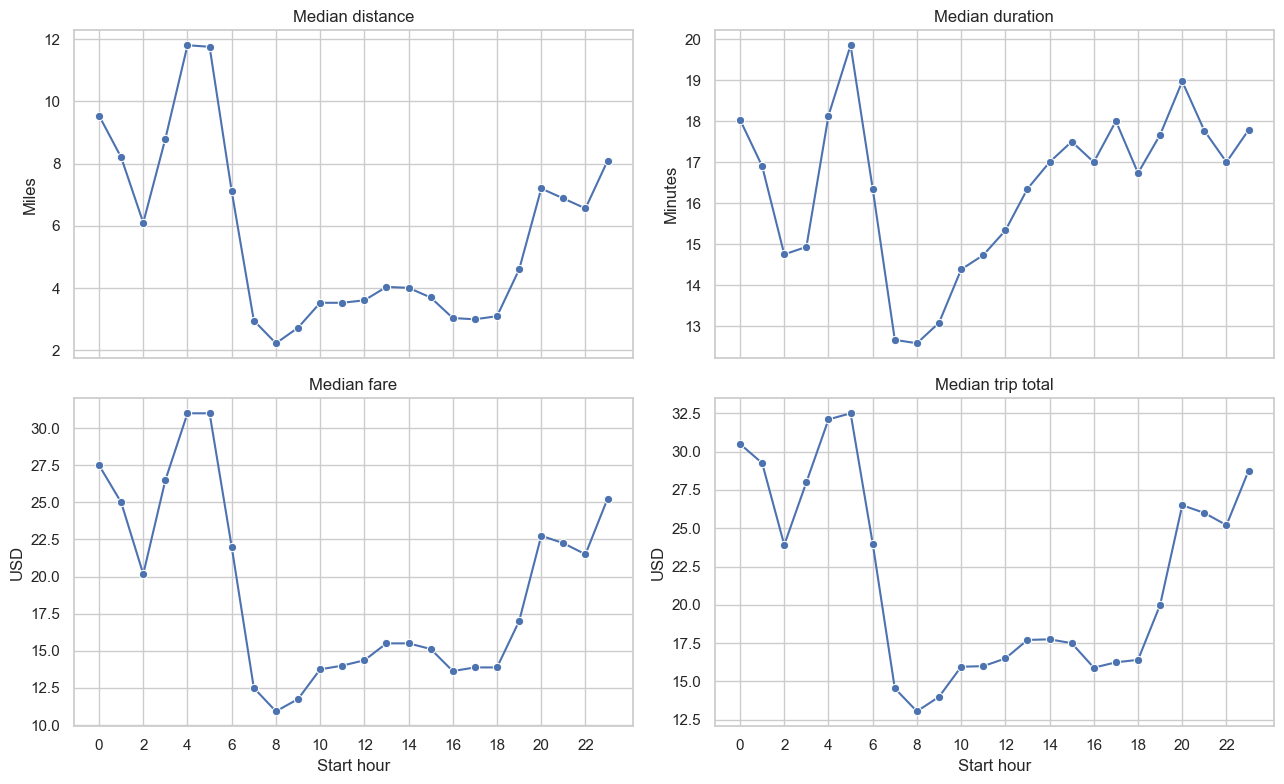

In [44]:
hourly_characteristics = con.sql("""
SELECT
    EXTRACT('hour' FROM trip_start_timestamp)::INTEGER AS hour,
    COUNT(*) AS trips,
    MEDIAN(trip_miles) AS median_miles,
    MEDIAN(trip_seconds) / 60.0 AS median_minutes,
    MEDIAN(fare) AS median_fare,
    MEDIAN(trip_total) AS median_total
FROM full_trips
GROUP BY 1
ORDER BY 1
""").df()

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
series = [
    ("median_miles", "Median distance", "Miles"),
    ("median_minutes", "Median duration", "Minutes"),
    ("median_fare", "Median fare", "USD"),
    ("median_total", "Median trip total", "USD"),
]
for ax, (column, title, ylabel) in zip(axes.flat, series):
    sns.lineplot(data=hourly_characteristics, x="hour", y=column, marker="o", ax=ax)
    ax.set(title=title, xlabel="Start hour", ylabel=ylabel)
    ax.set_xticks(range(0, 24, 2))

fig.tight_layout()
plt.show()

## Community Area pickup and drop-off patterns

Pickup and drop-off totals are aggregated by Community Area. Both maps use the same logarithmic colour scale, allowing their levels to be compared directly.

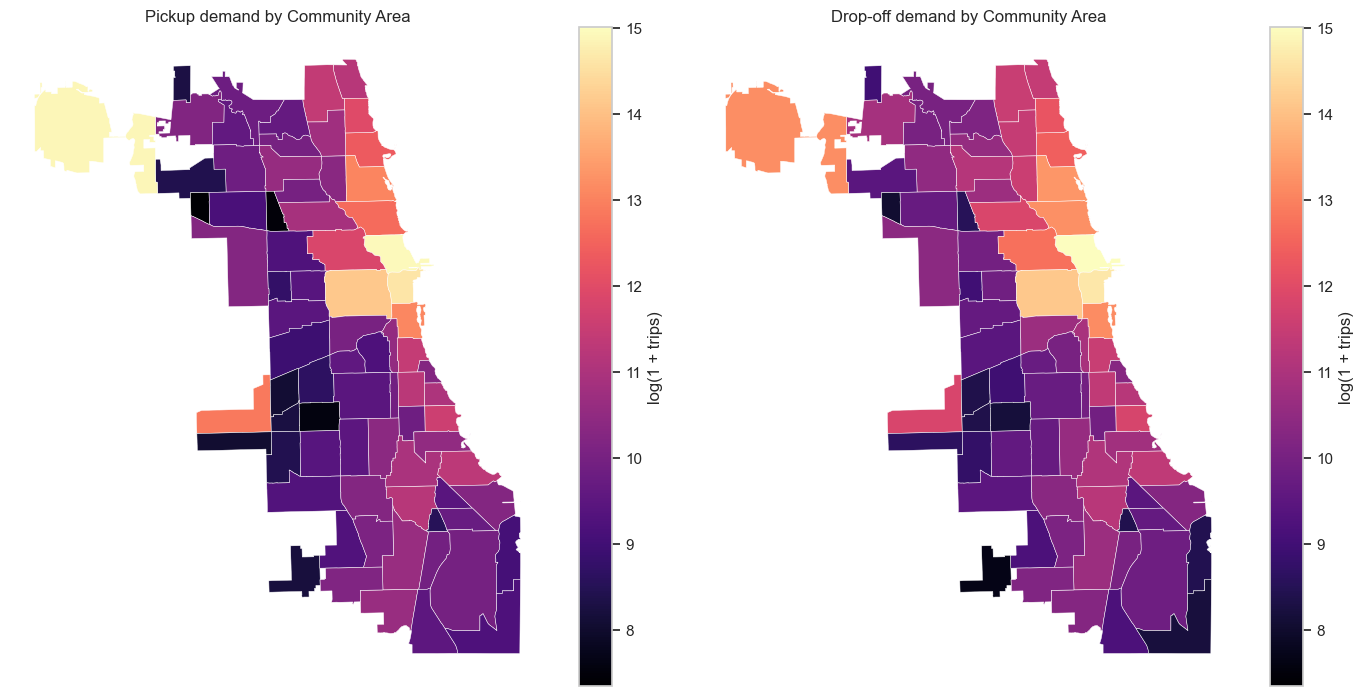

In [45]:
community_areas = gpd.read_parquet(COMMUNITY_PATH)
community_areas["community_area"] = pd.to_numeric(
    community_areas["AREA_NUM_1"], errors="coerce"
).astype("Int64")
community_areas["community_name"] = community_areas["COMMUNITY"].str.title()

community_demand = con.sql("""
WITH pickups AS (
    SELECT pickup_community_area::BIGINT AS community_area, COUNT(*) AS pickups
    FROM full_trips
    WHERE pickup_community_area IS NOT NULL
    GROUP BY 1
), dropoffs AS (
    SELECT dropoff_community_area::BIGINT AS community_area, COUNT(*) AS dropoffs
    FROM full_trips
    WHERE dropoff_community_area IS NOT NULL
    GROUP BY 1
)
SELECT
    COALESCE(p.community_area, d.community_area) AS community_area,
    COALESCE(p.pickups, 0) AS pickups,
    COALESCE(d.dropoffs, 0) AS dropoffs
FROM pickups p
FULL OUTER JOIN dropoffs d USING (community_area)
""").df()

community_map = community_areas.merge(community_demand, on="community_area", how="left")
community_map[["pickups", "dropoffs"]] = community_map[["pickups", "dropoffs"]].fillna(0)
community_map["log_pickups"] = np.log1p(community_map.pickups)
community_map["log_dropoffs"] = np.log1p(community_map.dropoffs)

common_vmin = min(community_map.log_pickups.min(), community_map.log_dropoffs.min())
common_vmax = max(community_map.log_pickups.max(), community_map.log_dropoffs.max())

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
for ax, column, title in [
    (axes[0], "log_pickups", "Pickup demand by Community Area"),
    (axes[1], "log_dropoffs", "Drop-off demand by Community Area"),
]:
    community_map.plot(
        column=column,
        cmap="magma",
        vmin=common_vmin,
        vmax=common_vmax,
        linewidth=0.35,
        edgecolor="white",
        legend=True,
        legend_kwds={"label": "log(1 + trips)"},
        ax=ax,
    )
    ax.set_title(title)
    ax.set_axis_off()

fig.tight_layout()
plt.show()

In [46]:
community_table = (
    community_map[["community_area", "community_name", "pickups", "dropoffs"]]
    .assign(
        pickup_share_pct=lambda frame: 100 * frame.pickups / frame.pickups.sum(),
        dropoff_share_pct=lambda frame: 100 * frame.dropoffs / frame.dropoffs.sum(),
        pickup_dropoff_ratio=lambda frame: frame.pickups / frame.dropoffs.replace(0, np.nan),
    )
    .sort_values("pickups", ascending=False)
)

display(community_table.head(15).round(2))

concentration_summary = pd.Series({
    "top_5_pickup_share_pct": community_table.head(5).pickup_share_pct.sum(),
    "top_10_pickup_share_pct": community_table.head(10).pickup_share_pct.sum(),
    "top_5_dropoff_share_pct": community_table.nlargest(5, "dropoffs").dropoff_share_pct.sum(),
    "top_10_dropoff_share_pct": community_table.nlargest(10, "dropoffs").dropoff_share_pct.sum(),
})
display(concentration_summary.to_frame("value").round(2))

,community_area,community_name,pickups,dropoffs,pickup_share_pct,dropoff_share_pct,pickup_dropoff_ratio
7,8,Near North Side,3058013,3298822,22.840,26.650,0.930
75,76,Ohare,2859309,533248,21.360,4.310,5.360
31,32,Loop,2228422,2294015,16.650,18.540,0.970
27,28,Near West Side,1376721,1355362,10.280,10.950,1.020
32,33,Near South Side,471855,523365,3.520,4.230,0.900
5,6,Lake View,457724,605782,3.420,4.890,0.760
55,56,Garfield Ridge,389363,136744,2.910,1.100,2.850
6,7,Lincoln Park,301512,556132,2.250,4.490,0.540
2,3,Uptown,226149,247704,1.690,2.000,0.910
76,77,Edgewater,156719,200120,1.170,1.620,0.780


,value
top_5_pickup_share_pct,74.660
top_10_pickup_share_pct,86.100
top_5_dropoff_share_pct,65.530
top_10_dropoff_share_pct,80.370


## Approximate idle time between observed trips

The data do not contain idle time. As an approximation, the analysis measures the gap between a taxi's previous published trip end and its next trip start. Only gaps from 0 to 12 hours are retained. Because timestamps are rounded to 15 minutes and shifts or periods outside the observed market are unknown, this measure is an inter-trip gap rather than exact vehicle idle time.

In [47]:
idle_time_summary = con.sql("""
WITH ordered AS (
    SELECT
        taxi_id,
        trip_start_timestamp,
        LAG(trip_end_timestamp) OVER (
            PARTITION BY taxi_id ORDER BY trip_start_timestamp
        ) AS previous_end
    FROM full_trips
), gaps AS (
    SELECT
        DATE_DIFF('minute', previous_end, trip_start_timestamp) AS gap_minutes
    FROM ordered
    WHERE previous_end IS NOT NULL
)
SELECT
    COUNT(*) AS retained_gaps,
    AVG(gap_minutes) AS mean_minutes,
    MEDIAN(gap_minutes) AS median_minutes,
    QUANTILE_CONT(gap_minutes, 0.25) AS p25_minutes,
    QUANTILE_CONT(gap_minutes, 0.75) AS p75_minutes,
    QUANTILE_CONT(gap_minutes, 0.95) AS p95_minutes
FROM gaps
WHERE gap_minutes BETWEEN 0 AND 720
""").df()

display(idle_time_summary.round(2))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,retained_gaps,mean_minutes,median_minutes,p25_minutes,p75_minutes,p95_minutes
0,11758953,68.450,30.000,15.000,75.000,255.000


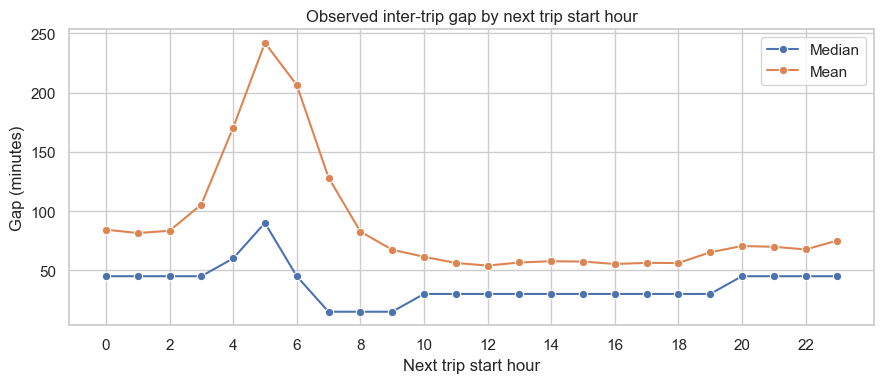

In [48]:
idle_by_next_start_hour = con.sql("""
WITH ordered AS (
    SELECT
        taxi_id,
        trip_start_timestamp,
        LAG(trip_end_timestamp) OVER (
            PARTITION BY taxi_id ORDER BY trip_start_timestamp
        ) AS previous_end
    FROM full_trips
), gaps AS (
    SELECT
        EXTRACT('hour' FROM trip_start_timestamp)::INTEGER AS next_start_hour,
        DATE_DIFF('minute', previous_end, trip_start_timestamp) AS gap_minutes
    FROM ordered
    WHERE previous_end IS NOT NULL
)
SELECT
    next_start_hour,
    COUNT(*) AS gaps,
    AVG(gap_minutes) AS mean_minutes,
    MEDIAN(gap_minutes) AS median_minutes
FROM gaps
WHERE gap_minutes BETWEEN 0 AND 720
GROUP BY 1
ORDER BY 1
""").df()

fig, ax = plt.subplots(figsize=(9, 4))
sns.lineplot(data=idle_by_next_start_hour, x="next_start_hour", y="median_minutes", marker="o", label="Median", ax=ax)
sns.lineplot(data=idle_by_next_start_hour, x="next_start_hour", y="mean_minutes", marker="o", label="Mean", ax=ax)
ax.set(
    title="Observed inter-trip gap by next trip start hour",
    xlabel="Next trip start hour",
    ylabel="Gap (minutes)",
)
ax.set_xticks(range(0, 24, 2))
plt.tight_layout()
plt.show()

## Spatial and temporal resolution comparison

The comparison uses the same 6,049,435 trips for Community Areas, canonical Census Tracts, H3 r7 and H3 r8. H3 cells are assigned from the published pickup centroids.

Each spatial system is evaluated in 1-hour, 4-hour and 24-hour bins. The panel contains every valid spatial-unit/time-bin combination, including zeros. Statistics for active bins are kept separate from the share of zero-demand bins.

In [49]:
coordinate_h3 = con.sql("""
SELECT DISTINCT
    pickup_centroid_latitude AS latitude,
    pickup_centroid_longitude AS longitude
FROM common_trips
WHERE pickup_centroid_latitude IS NOT NULL
  AND pickup_centroid_longitude IS NOT NULL
""").df()

for resolution in H3_RESOLUTION:
    coordinate_h3[f"h3_{resolution}"] = [
        h3.latlng_to_cell(latitude, longitude, resolution)
        for latitude, longitude in zip(coordinate_h3.latitude, coordinate_h3.longitude)
    ]

con.register("coordinate_h3", coordinate_h3)
con.execute("""
CREATE OR REPLACE VIEW common_spatial AS
SELECT t.*, m.h3_7, m.h3_8
FROM common_trips t
JOIN coordinate_h3 m
  ON t.pickup_centroid_latitude = m.latitude
 AND t.pickup_centroid_longitude = m.longitude
""")

spatial_mapping_quality = con.sql("""
SELECT
    COUNT(*) AS trips,
    COUNT(pickup_community_area) AS community_mapped,
    COUNT(pickup_census_tract) AS census_mapped,
    COUNT(h3_7) AS h3_7_mapped,
    COUNT(h3_8) AS h3_8_mapped
FROM common_spatial
""").df()
display(spatial_mapping_quality)

mapped_counts = spatial_mapping_quality.iloc[0]
assert mapped_counts.nunique() == 1, "Spatial systems do not contain identical trip populations"

,trips,community_mapped,census_mapped,h3_7_mapped,h3_8_mapped
0,6049435,6049435,6049435,6049435,6049435


In [50]:
census_tracts = gpd.read_parquet(PATHS.silver_census_tracts)

dimension_sizes = {
    "Community Areas": int(community_areas.community_area.nunique()),
    "Census Tracts": int(
        pd.to_numeric(census_tracts["CENSUS_T_1"], errors="coerce").nunique()
    ),
}
for resolution in H3_RESOLUTION:
    dimension_sizes[f"H3 r{resolution}"] = con.execute(
        "SELECT COUNT(DISTINCT h3_cell) FROM read_parquet(?)",
        [str(PATHS.silver_hexagons[resolution])],
    ).fetchone()[0]

display(pd.Series(dimension_sizes, name="spatial_units").to_frame())

,spatial_units
Community Areas,77
Census Tracts,878
H3 r7,163
H3 r8,976


### Complete-panel sparsity and active-bin characteristics

`zero_bin_share_pct` is calculated over the complete panel. All other distributions in this section use bins with at least one trip. Their medians are unweighted across bins and therefore describe a typical active spatial-time bin, not a typical citywide trip.

In [51]:
spatial_specs = {
    "Community Areas": "CAST(pickup_community_area AS VARCHAR)",
    "Census Tracts": "CAST(pickup_census_tract AS VARCHAR)",
    "H3 r7": "h3_7",
    "H3 r8": "h3_8",
}
time_specs = {
    "1h": ("DATE_TRUNC('hour', trip_start_timestamp)", 1),
    "4h": ("TIME_BUCKET(INTERVAL '4 hours', trip_start_timestamp)", 4),
    "24h": ("DATE_TRUNC('day', trip_start_timestamp)", 24),
}

comparison_rows = []
configured_start = pd.Timestamp(START_DATE)
configured_end = pd.Timestamp(END_DATE)
expected_common_trips = int(coverage.loc[0, "common_trips"])

for spatial_label, spatial_expression in spatial_specs.items():
    for time_label, (time_expression, bucket_hours) in time_specs.items():
        positive_metrics = con.execute(f"""
            WITH occupied AS (
                SELECT
                    {spatial_expression} AS spatial_unit,
                    {time_expression} AS time_bucket,
                    COUNT(*) AS trip_count,
                    MEDIAN(trip_miles) AS median_miles,
                    MEDIAN(trip_seconds) / 60.0 AS median_minutes,
                    MEDIAN(fare) AS median_fare
                FROM common_spatial
                WHERE {spatial_expression} IS NOT NULL
                GROUP BY 1, 2
            )
            SELECT
                COUNT(*) AS positive_bins,
                SUM(trip_count) AS represented_trips,
                AVG(trip_count) AS mean_trips_positive,
                MEDIAN(trip_count) AS median_trips_positive,
                QUANTILE_CONT(trip_count, 0.95) AS p95_trips_positive,
                100.0 * AVG(CASE WHEN trip_count < 5 THEN 1 ELSE 0 END)
                    AS positive_bins_below_5_pct,
                MEDIAN(median_miles) AS typical_bin_median_miles,
                MEDIAN(median_minutes) AS typical_bin_median_minutes,
                MEDIAN(median_fare) AS typical_bin_median_fare
            FROM occupied
        """).fetchdf().iloc[0].to_dict()

        n_time_buckets = int(
            (configured_end - configured_start) / pd.Timedelta(hours=bucket_hours)
        )
        total_bins = dimension_sizes[spatial_label] * n_time_buckets
        positive_bins = int(positive_metrics["positive_bins"])
        represented_trips = int(positive_metrics["represented_trips"])
        if represented_trips != expected_common_trips:
            raise ValueError(
                f"{spatial_label} x {time_label} represents {represented_trips:,} "
                f"instead of {expected_common_trips:,} common trips"
            )

        comparison_rows.append({
            "spatial_unit": spatial_label,
            "time_unit": time_label,
            "spatial_units": dimension_sizes[spatial_label],
            "time_buckets": n_time_buckets,
            "total_bins": total_bins,
            "zero_bin_share_pct": 100.0 * (total_bins - positive_bins) / total_bins,
            **positive_metrics,
        })

resolution_comparison = pd.DataFrame(comparison_rows)
spatial_order = ["Community Areas", "Census Tracts", "H3 r7", "H3 r8"]
time_order = ["1h", "4h", "24h"]
resolution_comparison["spatial_unit"] = pd.Categorical(
    resolution_comparison.spatial_unit, categories=spatial_order, ordered=True
)
resolution_comparison["time_unit"] = pd.Categorical(
    resolution_comparison.time_unit, categories=time_order, ordered=True
)
resolution_comparison = resolution_comparison.sort_values(["spatial_unit", "time_unit"])

display(resolution_comparison.round(2))

,spatial_unit,time_unit,spatial_units,time_buckets,total_bins,zero_bin_share_pct,positive_bins,represented_trips,mean_trips_positive,median_trips_positive,p95_trips_positive,positive_bins_below_5_pct,typical_bin_median_miles,typical_bin_median_minutes,typical_bin_median_fare
0,Community Areas,1h,77,20424,1572648,91.580,"132,349.000","6,049,435.000",45.710,14.000,185.000,31.390,2.850,13.580,12.500
1,Community Areas,4h,77,5106,393162,87.730,"48,241.000","6,049,435.000",125.400,18.000,646.000,31.980,3.740,14.770,14.540
2,Community Areas,24h,77,851,65527,76.760,"15,228.000","6,049,435.000",397.260,13.000,"2,272.300",38.250,5.470,17.000,18.690
3,Census Tracts,1h,878,20424,17932272,98.030,"352,981.000","6,049,435.000",17.140,7.000,72.000,41.130,1.610,10.400,9.380
4,Census Tracts,4h,878,5106,4483068,96.840,"141,831.000","6,049,435.000",42.650,9.000,219.000,37.950,1.780,10.920,9.750
5,Census Tracts,24h,878,851,747178,93.420,"49,151.000","6,049,435.000",123.080,9.000,731.000,38.990,2.580,12.770,11.660
6,H3 r7,1h,163,20424,3329112,95.250,"158,077.000","6,049,435.000",38.270,9.000,189.000,36.320,2.690,13.300,12.000
7,H3 r7,4h,163,5106,832278,92.810,"59,870.000","6,049,435.000",101.040,12.000,621.000,34.170,3.100,14.120,13.250
8,H3 r7,24h,163,851,138713,85.950,"19,485.000","6,049,435.000",310.470,13.000,"2,215.000",36.470,4.770,16.140,16.900
9,H3 r8,1h,976,20424,19933824,98.520,"294,735.000","6,049,435.000",20.520,7.000,87.000,39.610,1.710,10.770,9.500


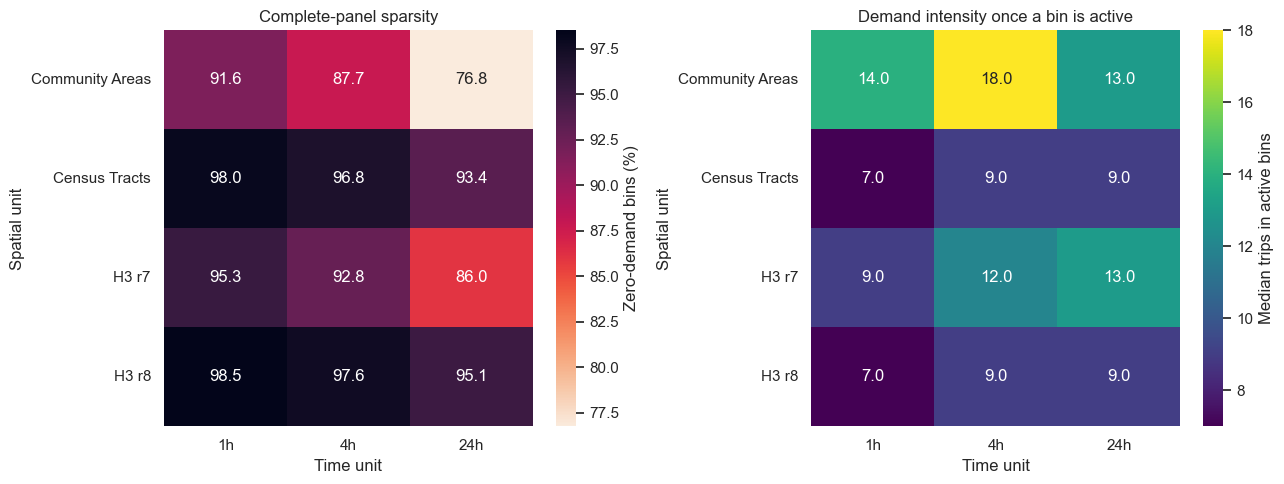

In [52]:
zero_matrix = resolution_comparison.pivot(
    index="spatial_unit", columns="time_unit", values="zero_bin_share_pct"
).reindex(index=spatial_order, columns=time_order)
positive_median_matrix = resolution_comparison.pivot(
    index="spatial_unit", columns="time_unit", values="median_trips_positive"
).reindex(index=spatial_order, columns=time_order)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.heatmap(
    zero_matrix,
    annot=True,
    fmt=".1f",
    cmap="rocket_r",
    cbar_kws={"label": "Zero-demand bins (%)"},
    ax=axes[0],
)
axes[0].set(title="Complete-panel sparsity", xlabel="Time unit", ylabel="Spatial unit")

sns.heatmap(
    positive_median_matrix,
    annot=True,
    fmt=".1f",
    cmap="viridis",
    cbar_kws={"label": "Median trips in active bins"},
    ax=axes[1],
)
axes[1].set(title="Demand intensity once a bin is active", xlabel="Time unit", ylabel="Spatial unit")

fig.tight_layout()
plt.show()

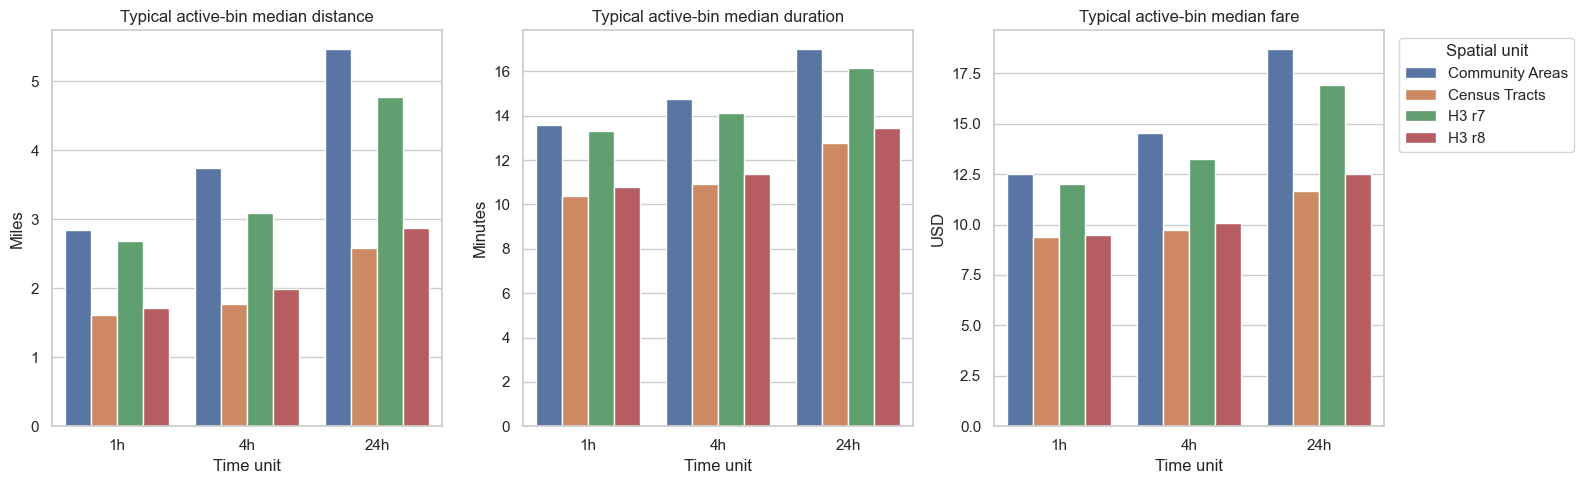

In [53]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
characteristic_specs = [
    ("typical_bin_median_miles", "Typical active-bin median distance", "Miles"),
    ("typical_bin_median_minutes", "Typical active-bin median duration", "Minutes"),
    ("typical_bin_median_fare", "Typical active-bin median fare", "USD"),
]
for ax, (column, title, ylabel) in zip(axes, characteristic_specs):
    sns.barplot(
        data=resolution_comparison,
        x="time_unit",
        y=column,
        hue="spatial_unit",
        hue_order=spatial_order,
        ax=ax,
    )
    ax.set(title=title, xlabel="Time unit", ylabel=ylabel)
    if ax is not axes[-1]:
        ax.get_legend().remove()
    else:
        ax.legend(title="Spatial unit", bbox_to_anchor=(1.02, 1), loc="upper left")

fig.tight_layout()
plt.show()

## Summary and limitations

- The cleaned dataset contains 13,386,706 trips. The common population used for the spatial comparison contains 6,049,435 trips (45.19%), mainly because many records lack a published Census source ID.
- Demand peaks at 17:00 with about 1,156 pickups per date-hour and is lowest at 03:00 with about 59. Thursday has the highest average daily demand (18,098 trips), while Sunday has the lowest (12,059). Average daily demand ranges from about 11,700 in January 2024 to 18,989 in June 2025.
- Mean distance and duration are 7.15 miles and 21.06 minutes; the corresponding medians are 3.91 miles and 16.05 minutes. Mean fare is USD 22.07 and median fare USD 15.25. Trips starting around 04:00–05:00 are longer and more expensive in the median. Airport trips may contribute to this pattern, but trip purpose is not observed.
- Near North Side, O'Hare, the Loop and Near West Side dominate pickup demand. The five largest Community Areas contain 74.66% of mapped pickups and the ten largest contain 86.10%. O'Hare's pickup/drop-off ratio is about 5.36, although missing drop-off locations and publication rules limit this comparison.
- For gaps of up to 12 hours, the median observed inter-trip gap is 30 minutes and the mean is 68.45 minutes. Long gaps, especially before early-morning trips, pull up the mean. This is not an exact measure of physical idle time.
- Finer spatial units and shorter intervals produce more zero-demand bins. Larger units and longer intervals combine more demand. Since each configuration contains the same trips, the differences come from aggregation rather than coverage.
- Routes and congestion are not observed, and published centroids do not support street-level conclusions. The results describe associations rather than causal effects.